In [22]:
import os
import numpy as np
from pathlib import Path
from src.io.offline import load_raw_data
from src.signal.passivesonar import lofar
from src.signal.utils import resample

In [23]:
datapath = Path("./data/4classes/") 
raw_data = load_raw_data(datapath)

n_pts_fft = 1024
n_overlap = 0
decimation_rate = 3
final_fs = 22050//decimation_rate

raw_data = raw_data.apply(lambda rr: resample(rr['signal'], rr['fs'], final_fs = final_fs))
lofar_data = raw_data.apply(lofar,
                            fs=final_fs,
                            n_pts_fft = n_pts_fft, 
                            n_overlap=n_overlap, 
                            spectrum_bins_left=512)

class_map = {
    "ClassA": 0,
    "ClassB": 1,
    "ClassC": 2,
    "ClassD": 3,
}

trgt = np.concatenate([class_map[cls_name]*np.ones(Sxx.shape[0])
                 for cls_name, run in lofar_data.items() 
                 for run_name, (Sxx, _, _) in run.items()])

data = np.concatenate([ Sxx
                 for cls_name, run in lofar_data.items() 
                 for run_name, (Sxx, _, _) in run.items()], axis=0)
data.shape

(25844, 512)

In [3]:
import itertools
import random

# class LoroCV:
#     def __init__(self, n_splits, shuffle=True, window_size=None, overlap=None):
#         self.shuffle = shuffle
#         self.n_splits = n_splits
#         self.window_size = window_size
#         self.overlap = overlap

#     def split(self, lofar_data):
#         ship_sets, ship_cycles = self._prepare_cycler(lofar_data)
#         for _ in range(self.n_splits):
#             test_ship_list = list()
#             train_ship_list = list()
#             for cls_name, run in lofar_data.items():
#                 cls_ship_set = ship_sets[cls_name]
#                 cls_ship_cycle = ship_cycles[cls_name]

#                 test_ship = next(cls_ship_cycle)
#                 train_ships = cls_ship_set - {test_ship}

#                 test_ship_list.extend([(cls_name, test_ship)])
#                 train_ship_list.extend([(cls_name, ship) for ship in train_ships])
#             # print(test_ship_list)
#             # print(train_ship_list)
#             # print()
#             # print()
#             X_train, y_train = self.flatten(lofar_data, train_ship_list)
#             X_test, y_test = self.flatten(lofar_data, test_ship_list)

#             yield X_train, y_train, X_test, y_test

#     def flatten(self, lofar_data, ship_list):
#         trgt, data = list(), list()
#         for cls_name, ship in ship_list:
#             Sxx, _, _ = lofar_data[cls_name][ship]

#             # Sxx windowing, must check if its working properly
#             if self.window_size and self.overlap:
#                 H = self.window_size
#                 O = self.overlap
#                 step = H - O
#                 windows = [Sxx[i:i+H] for i in range(0, Sxx.shape[0] - H + 1, step)]
#                 Sxx = np.array(windows)

#             trgt.append(class_map[cls_name] * np.ones(Sxx.shape[0]))
#             data.append(Sxx)
#         trgt = np.concatenate(trgt)
#         data = np.concatenate(data, axis=0)
#         return data, trgt

#     def _prepare_cycler(self, lofar_data):
#         shuffle = self.shuffle

#         ship_sets = dict()
#         ship_cycles = dict()
#         for cls_name, run in lofar_data.items():
#             keys_list = list(run.keys())  # Convert the keys to a list
#             if shuffle:
#                 random.shuffle(keys_list)  # Shuffle the list of keys

#             ship_sets[cls_name] = set(keys_list)  # Convert the shuffled list to a set
#             ship_cycles[cls_name] = itertools.cycle(keys_list)  # Create a cycle from the shuffled list

#         return ship_sets, ship_cycles

lorocv = LoroCV(n_splits=10)
for X_train, y_train, X_test, y_test in lorocv.split(lofar_data):
    print(X_train.shape)
    print(y_train.shape)

    print(X_test.shape)
    print(y_test.shape)



(22865, 512)
(22865,)
(2979, 512)
(2979,)
(22544, 512)
(22544,)
(3300, 512)
(3300,)
(22993, 512)
(22993,)
(2851, 512)
(2851,)
(22668, 512)
(22668,)
(3176, 512)
(3176,)
(23455, 512)
(23455,)
(2389, 512)
(2389,)
(22512, 512)
(22512,)
(3332, 512)
(3332,)
(23059, 512)
(23059,)
(2785, 512)
(2785,)
(22903, 512)
(22903,)
(2941, 512)
(2941,)
(21759, 512)
(21759,)
(4085, 512)
(4085,)
(23168, 512)
(23168,)
(2676, 512)
(2676,)


In [39]:
from src.data_handling import LoroCV
# Define window size and overlap
window_size = 10
overlap = 5

# Instantiate LoroCV with window size and overlap
lorocv_test = LoroCV(n_splits=2, window_size=window_size, overlap=overlap, random_seed=42)

# Run the split method and print the shapes of the resulting datasets
for X_train, y_train, X_test, y_test in lorocv_test.split(lofar_data):
    print("X_train shape:", X_train.shape)
    print("y_train shape:", y_train.shape)
    print("X_test shape:", X_test.shape)
    print("y_test shape:", y_test.shape)

X_train shape: (4573, 10, 512)
y_train shape: (4573,)
X_test shape: (547, 10, 512)
y_test shape: (547,)
X_train shape: (4563, 10, 512)
y_train shape: (4563,)
X_test shape: (557, 10, 512)
y_test shape: (557,)


: 

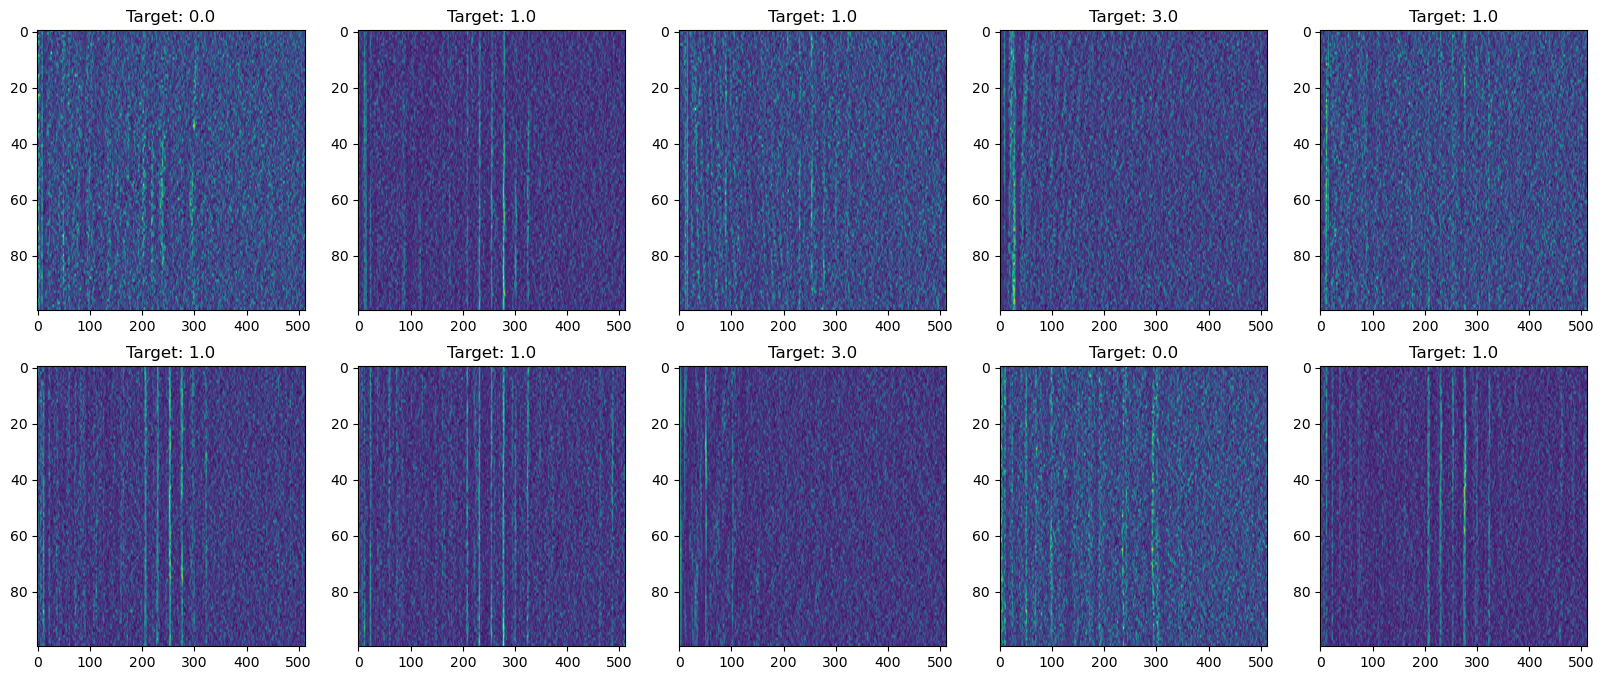

In [5]:
def plot_lofargram(Sxx, freq, time, ax=None, figsize=(10, 10), savepath=None):
    if ax is None:
        fig = plt.figure(figsize=figsize)
        ax = plt.gca()

    ax.imshow(Sxx, aspect='auto')

    if savepath is not None:
        fig.savefig(savepath, bbox_inches='tight')
        
    return ax
 
import matplotlib.pyplot as plt

# Plot a grid of examples from the windowed LoroCV for 2 folds
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

# Define window size and overlap
window_size = 100
overlap = 5
lorocv_test = LoroCV(n_splits=2, window_size=window_size, overlap=overlap)

for i, (X_train, y_train, X_test, y_test) in enumerate(lorocv_test.split(lofar_data)):
    if i >= 2:
        break
    indices = np.random.choice(X_test.shape[0], 5, replace=False)
    for j, idx in enumerate(indices):
        ax = axes[i, j]
        Sxx = X_test[idx]
        time = np.arange(Sxx.shape[1])
        freq = np.arange(Sxx.shape[0])
        plot_lofargram(Sxx, freq, time, ax=ax)
        ax.set_title(f"Target: {y_test[idx]}")
plt.show()

In [6]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import torch
from torch.utils.data import DataLoader, Dataset
from sklearn.manifold import TSNE
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight
import torch.nn.functional as F
from alive_progress import alive_bar
import seaborn as sns
import mplhep as hep
hep.style.use(hep.style.ATLAS)


def calculate_class_weights(y_train):
    # Compute class weights using sklearn's compute_class_weight
    class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
    # Convert the class weights to a PyTorch tensor
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)
    
    return class_weights_tensor

class CustomDataloader:
    def __init__(self, data, target, is2d=False):
        if is2d:
            data = torch.tensor(data.reshape(data.shape[0], 1, data.shape[1], data.shape[2]), dtype=torch.float32)
        else:
            data = torch.tensor(data.reshape(data.shape[0], -1), dtype=torch.float32)
        target = torch.tensor(target, dtype=torch.long)

        self.data = data
        self.target = target

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.target[idx]


class MLPClassifier(torch.nn.Module):
    def __init__(self, input_size, hidden_layer_sizes, output_size):
        super(MLPClassifier, self).__init__()
        
        layers = []
        in_size = input_size
        self.hidden_layers = torch.nn.ModuleList()  # Store hidden layers to access embeddings
        
        # Add hidden layers
        for hidden_size in hidden_layer_sizes:
            self.hidden_layers.append(torch.nn.Linear(in_size, hidden_size))
            self.hidden_layers.append(torch.nn.ReLU())
            in_size = hidden_size
        
        # Add output layer
        self.output_layer = torch.nn.Linear(in_size, output_size)

    def forward(self, x, embeddings=False):
        # Pass through the hidden layers
        for layer in self.hidden_layers:
            x = layer(x)

        if embeddings:
            return x  # Return activations from the last hidden layer with the predictions
        output = self.output_layer(x)
        
        # Pass through the output layer for final classification
        return output


def plot_tsne_embeddings(ax, embeddings_2d, targets, palette, title='t-SNE visualization of embeddings'):
    """
    Function to plot the 2D t-SNE embeddings on the provided axis.
    
    Parameters:
        fig (matplotlib.figure.Figure): The figure object.
        ax (matplotlib.axes.Axes): The axis on which to plot the t-SNE embeddings.
        embeddings_2d (numpy.ndarray): The 2D embeddings to plot.
        targets (numpy.ndarray): The target labels for color-coding the points.
        palette (list): A list of color codes corresponding to the classes.
    """
    # Map each target to its corresponding color
    colors = [palette[target] for target in targets]
    
    scatter = ax.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=colors, alpha=0.7, s=5)
    ax.set_title(title)
    ax.set_xlabel('t-SNE Component 1')
    ax.set_ylabel('t-SNE Component 2')
    
    # Optionally, add a legend
    handles = [plt.Line2D([], [], marker='o', color=palette[i], linestyle='', label=f'Class {i}') for i in range(len(palette))]
    ax.legend(handles=handles)

class Trainer:
    def __init__(self, model, optimizer, criterion, num_epochs=10, verbose=False, plotpath=None):
        self.model = model
        self.optimizer = optimizer
        self.criterion = criterion
        self.num_epochs = num_epochs
        self.verbose = verbose
        self.plotpath = plotpath

    def train(self, train_loader, test_loader):
        self.model.train()
        for epoch in range(self.num_epochs):
            epoch_loss = 0.0
            with alive_bar(len(train_loader), title=f"Training Epoch {epoch+1}/{self.num_epochs}") as bar:
                for batch_data, batch_target in train_loader:
                    self.optimizer.zero_grad()
                    output = self.model(batch_data)
                    loss = self.criterion(output, batch_target)
                    loss.backward()
                    self.optimizer.step()
                    epoch_loss += loss.item()
                    bar()
            val_loss, accuracy, precision, recall, f1, roc_auc = self.evaluate(test_loader)
            if self.verbose:
                print(f"Epoch {epoch+1}/{self.num_epochs}, Loss: {epoch_loss/len(train_loader):.4f}, "
                    f"Val Loss: {val_loss:.4f}, Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, "
                    f"Recall: {recall}, F1 Score: {f1:.4f}, ROC AUC: {roc_auc:.4f}")
                
    def evaluate(self, test_loader):
        self.model.eval()
        all_preds = []
        all_targets = []
        val_loss = 0.0
        with torch.no_grad():
            for batch_data, batch_target in test_loader:
                output = self.model(batch_data)
                _, preds = torch.max(output, 1)
                all_preds.extend(preds.cpu().numpy())
                all_targets.extend(batch_target.cpu().numpy())
                val_loss += self.criterion(output, batch_target).item()

        val_loss /= len(test_loader)
        y_pred = np.array(all_preds)
        y_target = np.array(all_targets)
        
        accuracy = np.mean(recall_score(y_target, y_pred, average=None))
        precision = precision_score(y_target, y_pred, average='weighted')
        recall = recall_score(y_target, y_pred, average=None)
        f1 = f1_score(y_target, y_pred, average='weighted')
        roc_auc = roc_auc_score(label_binarize(y_target, classes=[0, 1, 2, 3]), 
                                label_binarize(y_pred, classes=[0, 1, 2, 3]), 
                                average='weighted', multi_class='ovr')

        return val_loss, accuracy, precision, recall, f1, roc_auc


    def evaluate_embeddings(self, test_loader, fig=None, ax=None, path=None):
        """
        Evaluates the embeddings using t-SNE for visualization.
        """
        self.model.eval()
        all_embeddings = []
        all_targets = []

        with torch.no_grad():
            for batch_data, batch_target in test_loader:
                # Extract embeddings (before final output layer)
                embeddings = self.model(batch_data, embeddings=True)
                all_embeddings.append(embeddings.cpu().numpy())
                all_targets.extend(batch_target.cpu().numpy())

        # Concatenate all embeddings into one array
        all_embeddings = np.concatenate(all_embeddings, axis=0)
        all_targets = np.array(all_targets)

        # Apply t-SNE for dimensionality reduction (reduce to 2D)
        tsne = TSNE(n_components=2, random_state=42)
        embeddings_2d = tsne.fit_transform(all_embeddings)

        return embeddings_2d, all_targets




## Test classififer

Training Epoch 1/10 |████████████████████████████████████████| 722/722 [100%] in 1.5s (476.95/s) 
Epoch 1/10, Loss: 0.5298, Val Loss: 0.5157, Accuracy: 0.7784, Precision: 0.8330, Recall: [0.92334495 0.66888151 0.6121673  0.90934449], F1 Score: 0.8128, ROC AUC: 0.8765
Training Epoch 2/10 |████████████████████████████████████████| 722/722 [100%] in 0.5s (1560.10/s) 
Epoch 2/10, Loss: 0.3047, Val Loss: 0.4646, Accuracy: 0.7876, Precision: 0.8398, Recall: [0.93728223 0.71539313 0.58555133 0.91213389], F1 Score: 0.8283, ROC AUC: 0.8864
Training Epoch 3/10 |████████████████████████████████████████| 722/722 [100%] in 0.4s (1646.53/s) 
Epoch 3/10, Loss: 0.2565, Val Loss: 0.4573, Accuracy: 0.7900, Precision: 0.8442, Recall: [0.93379791 0.73754153 0.57794677 0.91073919], F1 Score: 0.8340, ROC AUC: 0.8895
Training Epoch 4/10 |████████████████████████████████████████| 722/722 [100%] in 0.5s (1583.48/s) 
Epoch 4/10, Loss: 0.2222, Val Loss: 0.4914, Accuracy: 0.7775, Precision: 0.8335, Recall: [0.930

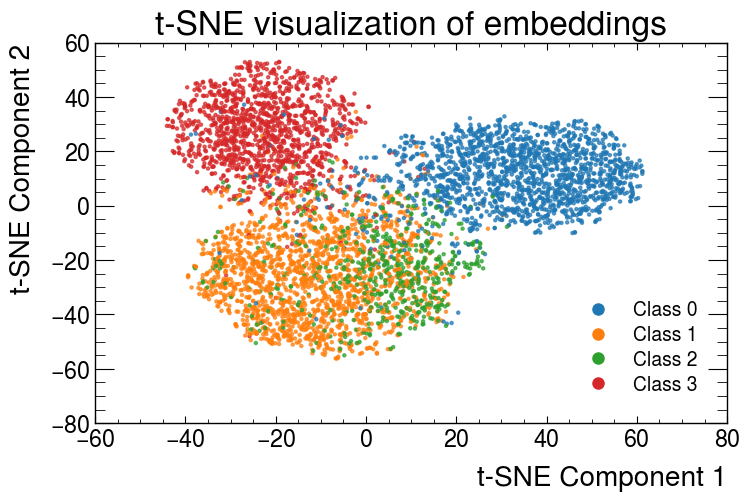

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Initialize the model, optimizer, and criterion
hidden_layer_sizes = [16]
output_size = len(np.unique(y_train))

# Perform cross-validation using LoroCV
accuracies = []
embeddings = []
all_targets    = []
lorocv_no_window = LoroCV(n_splits=2, window_size=None, overlap=None)
for i, (X_train, y_train, X_test, y_test) in enumerate(lorocv_no_window.split(lofar_data)):
    # Compute class weights for loss balancing
    class_weights = calculate_class_weights(y_train)

    # Standardize the data
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Create DataLoader instances for the fold
    train_dataset_fold = CustomDataloader(X_train, y_train)
    test_dataset_fold = CustomDataloader(X_test, y_test)
    train_loader_fold = DataLoader(train_dataset_fold, batch_size=32, shuffle=True)
    test_loader_fold = DataLoader(test_dataset_fold, batch_size=32, shuffle=False)

    # Initialize the model, optimizer, and criterion for the fold
    input_size = X_train.shape[1]
    mlp_fold = MLPClassifier(input_size, hidden_layer_sizes, output_size)
    optimizer_fold = torch.optim.Adam(mlp_fold.parameters(), lr=0.001)
    criterion_fold = torch.nn.CrossEntropyLoss(weight=class_weights)

    # Initialize and run the trainer for the fold
    trainer_fold = Trainer(mlp_fold, optimizer_fold, criterion_fold, num_epochs=10, verbose=True)
    trainer_fold.train(train_loader_fold, test_loader_fold)

    # Evaluate the model on the test fold
    _, accuracy, precision, recall, f1, roc_auc = trainer_fold.evaluate(test_loader_fold)

    # Evaluate the embeddings
    fold_embeddings, fold_targets = trainer_fold.evaluate_embeddings(test_loader_fold)
    embeddings.append(fold_embeddings)
    all_targets.append(fold_targets)

    accuracies.append(accuracy)

# Print the average accuracy
print(f"Average accuracy: {np.mean(accuracies)}")

embeddings = np.concatenate(embeddings, axis=0)
all_targets = np.concatenate(all_targets, axis=0)

palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
fig, ax = plt.subplots(figsize=(8, 8/ 1.618))
plot_tsne_embeddings(ax, embeddings, all_targets, palette=palette)
plt.show()

## Testing MtAE

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MultitaskAutoencoder(torch.nn.Module):
    def __init__(self, input_size, hidden_layer_sizes, output_size):
        super(MultitaskAutoencoder, self).__init__()
        
        layers = []
        in_size = input_size
        self.hidden_layers = torch.nn.ModuleList()  # Store hidden layers to access embeddings
        
        # Add hidden layers (Encoder)
        for hidden_size in hidden_layer_sizes:
            self.hidden_layers.append(torch.nn.Linear(in_size, hidden_size))
            self.hidden_layers.append(torch.nn.ReLU())
            in_size = hidden_size
        
        # Add output layer for classification
        self.output_layer = torch.nn.Linear(in_size, output_size)
        
        # Decoder part (to reconstruct the input)
        self.decoder_layers = torch.nn.ModuleList()
        for hidden_size in reversed(hidden_layer_sizes):
            self.decoder_layers.append(torch.nn.Linear(in_size, hidden_size))
            self.decoder_layers.append(torch.nn.ReLU())
            in_size = hidden_size
        
        # Final decoder layer to reconstruct the original input
        self.reconstruction_layer = torch.nn.Linear(in_size, input_size)

    def forward(self, x, embeddings=False):
        # Encoder: Pass through hidden layers
        for layer in self.hidden_layers:
            x = layer(x)
        
        if embeddings:
            return x  # Return classification output and embeddings

        # Classification output
        class_output = self.output_layer(x)
            
        # Decoder: Reconstruct the input
        reconstructed = x
        for layer in self.decoder_layers:
            reconstructed = layer(reconstructed)
        
        reconstructed = self.reconstruction_layer(reconstructed)
        
        return class_output, reconstructed
    
class MultitaskTrainer(Trainer):
    def __init__(
        self, 
        model, 
        optimizer, 
        classification_criterion, 
        reconstruction_criterion, 
        alpha=0.5, 
        num_epochs=10, 
        verbose=False, 
        plotpath=None
    ):
        super(MultitaskTrainer, self).__init__(model, optimizer, classification_criterion, num_epochs, verbose, plotpath)
        self.reconstruction_criterion = reconstruction_criterion
        self.alpha = alpha

    def train(self, train_loader, test_loader):
        self.model.train()
        for epoch in range(self.num_epochs):
            epoch_loss = 0.0
            rec_epoch_loss = 0.0
            clf_epoch_loss = 0.0
            with alive_bar(len(train_loader), title=f"Training Epoch {epoch+1}/{self.num_epochs}") as bar:
                for batch_data, batch_target in train_loader:
                    self.optimizer.zero_grad()
                    class_output, reconstructed = self.model(batch_data)
                    classification_loss = self.criterion(class_output, batch_target)
                    reconstruction_loss = self.reconstruction_criterion(reconstructed, batch_data)

                    total_loss = self.alpha * reconstruction_loss + (1 - self.alpha) * classification_loss

                    total_loss.backward()
                    self.optimizer.step()
                    epoch_loss += total_loss.item()
                    rec_epoch_loss += reconstruction_loss.item()
                    clf_epoch_loss += classification_loss.item()
                    bar()
            val_loss, accuracy, precision, recall, f1, roc_auc = self.evaluate(test_loader)
            if self.verbose:
                print(f"Epoch {epoch+1}/{self.num_epochs}, Total Loss: {epoch_loss/len(train_loader):.4f}, "
                      f"Classification Loss: {clf_epoch_loss/len(train_loader):.4f}, "
                      f"Reconstruction Loss: {rec_epoch_loss/len(train_loader):.4f}, "
                      f"Total Val Loss: {val_loss['total_loss']:.4f}"
                      f"Classification Val Loss: {val_loss['classification_loss']:.4f}"
                      f"Reconstruction Val Loss: {val_loss['reconstruction_loss']:.4f}, Accuracy: {accuracy:.4f}, "
                      f"Precision: {precision:.4f}, Recall: {recall}, "
                      f"F1 Score: {f1:.4f}, ROC AUC: {roc_auc:.4f}")
              
    def evaluate(self, test_loader):
        self.model.eval()
        all_preds = []
        all_targets = []
        val_total_loss = 0.0
        val_classification_loss = 0.0
        val_reconstruction_loss = 0.0
        with torch.no_grad():
            for batch_data, batch_target in test_loader:
                class_output, reconstructed = self.model(batch_data)

                classification_loss = self.criterion(class_output, batch_target)
                reconstruction_loss = self.reconstruction_criterion(reconstructed, batch_data)

                total_loss = self.alpha * 10 * reconstruction_loss + (1 - self.alpha) * classification_loss
                val_total_loss += total_loss.item()
                val_classification_loss += classification_loss.item()
                val_reconstruction_loss += reconstruction_loss.item()
                
                _, preds = torch.max(class_output, 1)
                all_preds.extend(preds.cpu().numpy())
                all_targets.extend(batch_target.cpu().numpy())

        val_total_loss /= len(test_loader)
        val_classification_loss /= len(test_loader)
        val_reconstruction_loss /= len(test_loader)
        
        y_pred = np.array(all_preds)
        y_target = np.array(all_targets)
        
        accuracy = np.mean(recall_score(y_target, y_pred, average=None))
        precision = precision_score(y_target, y_pred, average='weighted')
        recall = recall_score(y_target, y_pred, average=None)
        f1 = f1_score(y_target, y_pred, average='weighted')
        roc_auc = roc_auc_score(
            label_binarize(y_target, classes=[0, 1, 2, 3]),
            label_binarize(y_pred, classes=[0, 1, 2, 3]),
            average='weighted',
            multi_class='ovr'
        )

        val_loss = {
            'total_loss': val_total_loss,
            'classification_loss': val_classification_loss,
            'reconstruction_loss': val_reconstruction_loss
        }
        return val_loss, accuracy, precision, recall, f1, roc_auc
    


Training Epoch 1/10 |████████████████████████████████████████| 704/704 [100%] in 0.7s (1027.37/s) 
Epoch 1/10, Total Loss: 0.7620, Classification Loss: 0.5380, Reconstruction Loss: 0.9860, Total Val Loss: 5.0297Classification Val Loss: 0.4459Reconstruction Val Loss: 0.9613, Accuracy: 0.8031, Precision: 0.8273, Recall: [0.83949192 0.86558219 0.65420561 0.85331781], F1 Score: 0.8277, ROC AUC: 0.8833
Training Epoch 2/10 |████████████████████████████████████████| 704/704 [100%] in 0.8s (910.57/s) 
Epoch 2/10, Total Loss: 0.6321, Classification Loss: 0.3111, Reconstruction Loss: 0.9530, Total Val Loss: 4.9562Classification Val Loss: 0.4209Reconstruction Val Loss: 0.9492, Accuracy: 0.8046, Precision: 0.8362, Recall: [0.8591224  0.87071918 0.59345794 0.89522701], F1 Score: 0.8360, ROC AUC: 0.8901
Training Epoch 3/10 |████████████████████████████████████████| 704/704 [100%] in 0.7s (975.69/s) 
Epoch 3/10, Total Loss: 0.6041, Classification Loss: 0.2640, Reconstruction Loss: 0.9442, Total Val L

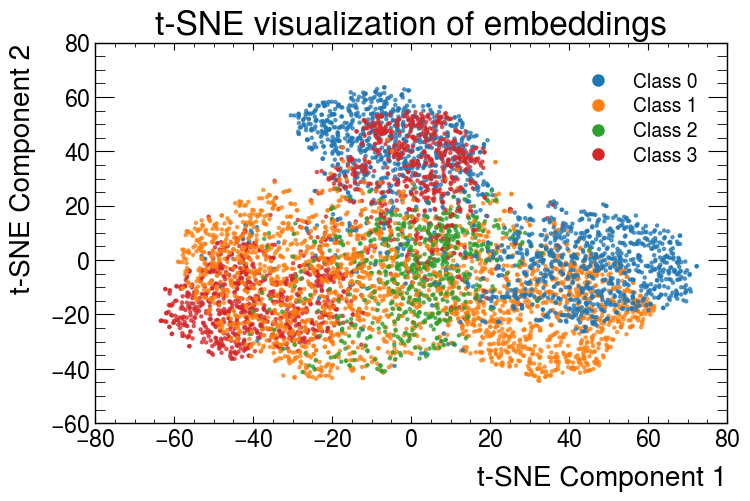

In [9]:

# Initialize the model, optimizer, and criterion
hidden_layer_sizes = [16]
output_size = len(np.unique(y_train))
alpha = 0.5

# Perform cross-validation using LoroCV
accuracies = []
embeddings = []
all_targets    = []
lorocv_no_window = LoroCV(n_splits=2, window_size=None, overlap=None)
for i, (X_train, y_train, X_test, y_test) in enumerate(lorocv_no_window.split(lofar_data)):
    # Compute class weights for loss balancing
    class_weights = calculate_class_weights(y_train)

    # Standardize the data
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Create DataLoader instances for the fold
    train_dataset_fold = CustomDataloader(X_train, y_train)
    test_dataset_fold = CustomDataloader(X_test, y_test)
    train_loader_fold = DataLoader(train_dataset_fold, batch_size=32, shuffle=True)
    test_loader_fold = DataLoader(test_dataset_fold, batch_size=32, shuffle=False)

    # Initialize the model, optimizer, and criterion for the fold
    input_size = X_train.shape[1]
    mlp_fold = MultitaskAutoencoder(input_size, hidden_layer_sizes, output_size)
    optimizer_fold = torch.optim.Adam(mlp_fold.parameters(), lr=0.001)
    
    clf_criterion_fold = torch.nn.CrossEntropyLoss(weight=class_weights)
    rec_criterion_fold = torch.nn.MSELoss()

    # Initialize and run the trainer for the fold
    trainer_fold = MultitaskTrainer(mlp_fold, optimizer_fold,         
                                    clf_criterion_fold, 
                                    rec_criterion_fold, 
                                    alpha=alpha,
                                    num_epochs=10, verbose=True)
    trainer_fold.train(train_loader_fold, test_loader_fold)

    # Evaluate the model on the test fold
    _, accuracy, precision, recall, f1, roc_auc = trainer_fold.evaluate(test_loader_fold)

    # Evaluate the embeddings
    fold_embeddings, fold_targets = trainer_fold.evaluate_embeddings(test_loader_fold)
    embeddings.append(fold_embeddings)
    all_targets.append(fold_targets)

    accuracies.append(accuracy)

# Print the average accuracy
print(f"Average accuracy: {np.mean(accuracies)}")

embeddings = np.concatenate(embeddings, axis=0)
all_targets = np.concatenate(all_targets, axis=0)

palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
fig, ax = plt.subplots(figsize=(8, 8/ 1.618))
plot_tsne_embeddings(ax, embeddings, all_targets, palette=palette)
plt.show()

## ConvAutoencoder Code

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class ConvAutoencoderMultitask(nn.Module):
    def __init__(self, input_height, input_width, num_classes, latent_dim_size=128, dropout_rate=0.5):
        super(ConvAutoencoderMultitask, self).__init__()
        
        self.input_height = input_height
        self.input_width = input_width
        self.dropout_rate = dropout_rate

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=5, stride=2, padding=2),  # Layer 1
            nn.ReLU(),
            # nn.MaxPool2d((1, 2)),  # Lateral pooling
            nn.Dropout2d(self.dropout_rate),  # Dropout for convolutional layers (spatial dropout)

            nn.Conv2d(16, 32, kernel_size=5, stride=2, padding=2),  # Layer 2
            nn.ReLU(),
            # nn.MaxPool2d((1, 2)),  # Lateral pooling
            nn.Dropout2d(self.dropout_rate),  # Dropout

            nn.Conv2d(32, 64, kernel_size=5, stride=2, padding=2),  # Layer 3
            nn.ReLU(),
            # nn.MaxPool2d((1, 2)),  # Lateral poolings
            nn.Dropout2d(self.dropout_rate),  # Dropout

            nn.Conv2d(64, latent_dim_size, kernel_size=5, stride=2, padding=2),  # Layer 4
            nn.ReLU(),
            # nn.MaxPool2d((1, 2)),  # Lateral pooling
            nn.Dropout2d(self.dropout_rate),  # Dropout
        )

        # Dynamically calculate the output dimensions
        dummy_input = torch.zeros(1, 1, input_height, input_width)
        dummy_output = self.encoder(dummy_input)
        final_height, final_width = dummy_output.size(2), dummy_output.size(3)
        self.final_height = final_height
        self.final_width = final_width
        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(latent_dim_size * final_height * final_width, 100),  # Layer 5
            nn.ReLU(),
            nn.Dropout(self.dropout_rate),  # Dropout for dense layers

            nn.Linear(100, num_classes)   # Layer 6
        )
        
        # # Decoder
        # self.decoder = nn.Sequential(
        #     nn.ConvTranspose2d(128, 64, kernel_size=5, stride=(1, 2), padding=2, output_padding=(0, 1)),  # Adjust for lateral pooling
        #     nn.ReLU(),
        #     nn.Dropout2d(dropout_rate),
        #     nn.ConvTranspose2d(64, 32, kernel_size=5, stride=(1, 2), padding=2, output_padding=(0, 1)),  # Adjust for lateral pooling
        #     nn.ReLU(),
        #     nn.Dropout2d(dropout_rate),
        #     nn.ConvTranspose2d(32, 16, kernel_size=5, stride=(1, 2), padding=2, output_padding=(0, 1)),  # Adjust for lateral pooling
        #     nn.ReLU(),
        #     nn.Dropout2d(dropout_rate),
        #     nn.ConvTranspose2d(16, 1, kernel_size=5, stride=(1, 2), padding=2, output_padding=(0, 1)),  # Adjust for lateral pooling
        #     nn.Sigmoid()
        # )
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=5, stride=2, padding=2, output_padding=1),  # Layer 4 inverse
            nn.ReLU(),
            nn.Dropout2d(self.dropout_rate),  # Dropout

            nn.ConvTranspose2d(64, 32, kernel_size=5, stride=2, padding=2, output_padding=1),   # Layer 3 inverse
            nn.ReLU(),
            nn.Dropout2d(self.dropout_rate),  # Dropout

            nn.ConvTranspose2d(32, 16, kernel_size=5, stride=2, padding=2, output_padding=1),   # Layer 2 inverse
            nn.ReLU(),
            nn.Dropout2d(self.dropout_rate),  # Dropout

            nn.ConvTranspose2d(16, 1, kernel_size=5, stride=2, padding=2, output_padding=1),    # Layer 1 inverse,
            nn.Sigmoid()  # Use sigmoid to scale the output to [0,1]
        )


    def calculate_final_dimensions(self):
        height, width = self.input_height, self.input_width
        for _ in range(4):  # Four convolutional layers
            height = math.ceil((height + 4 - 5) / 2 + 1)
            width = math.ceil((width + 4 - 5) / 2 + 1)
        return height, width

    def forward(self, x, embeddings=False):
        x = self.encoder(x)
        x_flat = x.view(x.size(0), -1)  # Flatten the output for the classifier
        if embeddings:
            return x_flat
        # print(x.shape)
        # x = x.view(x.size(0), 128, -1)  # Assuming the flattened size matches the decoder input size (needs to be checked)
        # print(x.shape)
        # print()
        # print(x.shape)
        # x_reshaped = x_flat.view(x.size(0), 128, self.final_height, self.final_width)  # Reshape for the decoder
        # print(x_reshaped.shape)
        reconstructed = self.decoder(x)

        class_output = self.classifier(x_flat)
        

        return class_output, reconstructed

# Example initialization and summary
model = ConvAutoencoderMultitask(input_height=10, input_width=400, num_classes=10, latent_dim_size=128, dropout_rate=0.5)
print(model)


ConvAutoencoderMultitask(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (1): ReLU()
    (2): Dropout2d(p=0.5, inplace=False)
    (3): Conv2d(16, 32, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (4): ReLU()
    (5): Dropout2d(p=0.5, inplace=False)
    (6): Conv2d(32, 64, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (7): ReLU()
    (8): Dropout2d(p=0.5, inplace=False)
    (9): Conv2d(64, 128, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (10): ReLU()
    (11): Dropout2d(p=0.5, inplace=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=3200, out_features=100, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=100, out_features=10, bias=True)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), output_padding=(1, 1))
    (1): ReLU()
    (2): Dropout2d(p=0.5, inplace=False)
    (3): ConvT

In [21]:
window_size = 16
latent_dim_size=32
overlap = 14
alpha = 0.5

# Perform cross-validation using LoroCV
accuracies = []
embeddings = []
all_targets    = []
lorocv_no_window = LoroCV(n_splits=2, window_size=window_size, overlap=overlap)
for i, (X_train, y_train, X_test, y_test) in enumerate(lorocv_no_window.split(lofar_data)):
    # Compute class weights for loss balancing
    class_weights = calculate_class_weights(y_train)
    print(y_test.shape)
    # Standardize the data
    # scaler = StandardScaler()
    # X_train = scaler.fit_transform(X_train)
    # X_test = scaler.transform(X_test)

    # Create DataLoader instances for the fold
    train_dataset_fold = CustomDataloader(X_train, y_train, is2d=True)
    test_dataset_fold = CustomDataloader(X_test, y_test, is2d=True)
    train_loader_fold = DataLoader(train_dataset_fold, batch_size=32, shuffle=True)
    test_loader_fold = DataLoader(test_dataset_fold, batch_size=32, shuffle=False)

    # Initialize the model, optimizer, and criterion for the fold
    input_size = X_train.shape[1]
    mlp_fold = ConvAutoencoderMultitask(input_height=window_size, 
                                        input_width=512, 
                                        num_classes=4, 
                                        latent_dim_size=128,
                                        dropout_rate=0.5)
    optimizer_fold = torch.optim.Adam(mlp_fold.parameters(), lr=0.001)
    
    clf_criterion_fold = torch.nn.CrossEntropyLoss(weight=class_weights)
    rec_criterion_fold = torch.nn.MSELoss()

    # Initialize and run the trainer for the fold
    trainer_fold = MultitaskTrainer(mlp_fold, optimizer_fold,         
                                    clf_criterion_fold, 
                                    rec_criterion_fold, 
                                    alpha=alpha,
                                    num_epochs=10, verbose=True)
    trainer_fold.train(train_loader_fold, test_loader_fold)

    # Evaluate the model on the test fold
    _, accuracy, precision, recall, f1, roc_auc = trainer_fold.evaluate(test_loader_fold)

    # Evaluate the embeddings
    fold_embeddings, fold_targets = trainer_fold.evaluate_embeddings(test_loader_fold)
    embeddings.append(fold_embeddings)
    all_targets.append(fold_targets)

    accuracies.append(accuracy)


(1568,)
Training Epoch 1/10 |████████████████████████████████████████| 348/348 [100%] in 24.3s (14.30/s) 
Epoch 1/10, Total Loss: 0.4414, Classification Loss: 0.8426, Reconstruction Loss: 0.0402, Total Val Loss: 0.2955Classification Val Loss: 0.2963Reconstruction Val Loss: 0.0295, Accuracy: 0.9436, Precision: 0.9395, Recall: [0.8254717  0.94889267 1.         1.        ], F1 Score: 0.9331, ROC AUC: 0.9569
Training Epoch 2/10 |███████████▉⚠︎                           | (!) 103/348 [30%] in 17.7s (5.80/s) 


KeyboardInterrupt: 

Average accuracy: 0.8120296689262207


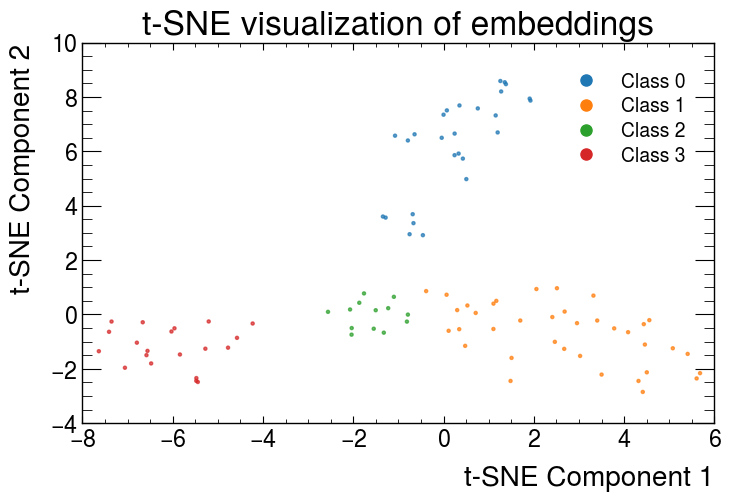

In [12]:

# Print the average accuracy
print(f"Average accuracy: {np.mean(accuracies)}")

embeddings0 = embeddings[0] #np.concatenate(embeddings, axis=0)
all_targets0 = all_targets[0] #np.concatenate(all_targets, axis=0)

palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
fig, ax = plt.subplots(figsize=(8, 8/ 1.618))
plot_tsne_embeddings(ax, embeddings0, all_targets0, palette=palette)
plt.show()

In [13]:
import torch
import torch.nn as nn


class MultitaskUNet(nn.Module):
    def __init__(self, input_height, input_width, num_classes, latent_dim_size=128):
        in_channels = 1
        out_channels = 1
        super(MultitaskUNet, self).__init__()
        self.height = input_height
        # Encoder
        self.encoder1 = self.conv_block(in_channels, 16)
        self.encoder2 = self.conv_block(16, 32)
        self.encoder3 = self.conv_block(32, 64)
        self.encoder4 = self.conv_block(64, latent_dim_size)
        # Bottleneck
        bottle_up = min(input_height//16, 2)
        self.bottleneck = self.conv_block(latent_dim_size, latent_dim_size)
        self.up_bottleneck = nn.ConvTranspose2d(
            in_channels=latent_dim_size, 
            out_channels=latent_dim_size, 
            kernel_size=(bottle_up, 2),  # To expand the width from 1 to 2
            stride=(bottle_up, 2),       # Keep the height dimension the same (1)
            padding=(0, 0)       # No padding needed, as we want to directly go from 1 to 2
        )
        
        # Decoder
        self.decoder4 = self.upconv_block(latent_dim_size + latent_dim_size, 64)  # concat + decoder channel size
        self.decoder3 = self.upconv_block(64 + 64, 32)   # concat + decoder channel size
        self.decoder2 = self.upconv_block(32 + 32, 16)   # concat + decoder channel size
        self.decoder1 = self.upconv_block(16 + 16, 16)        # Final output channels
        
        # Final layer
        self.final_conv = nn.Conv2d(16, out_channels, kernel_size=1)

        # Classification head
        self.classification_fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(latent_dim_size * 1 * 1, 32),  # Flatten the bottleneck output, adjust size if necessary
            nn.ReLU(inplace=True),
            nn.Linear(32, num_classes)   # Output number of classes
        )
    
    def conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=5, stride=2, padding=2),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=5, stride=(1,2), padding=(2,2)),
            nn.ReLU(inplace=True)
        )
    
    def upconv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size=5, stride=2, padding=2, output_padding=(1, 1)),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(out_channels, out_channels, kernel_size=5, stride=(1,2), padding=(2,2), output_padding=(0,1))
        )
    
    def forward(self, x, embeddings=False):
        # Encoder
        e1 = self.encoder1(x)
        e2 = self.encoder2(e1)
        e3 = self.encoder3(e2)
        e4 = self.encoder4(e3)

        # Bottleneck
        bottleneck = self.bottleneck(e4)
        bottleneck_up = self.up_bottleneck(bottleneck)

        # Decoder with skip connections (concatenation)
        d4 = self.decoder4(torch.cat((bottleneck_up, e4), dim=1))  # Concatenate skip connection
        d3 = self.decoder3(torch.cat((d4, e3), dim=1))
        d2 = self.decoder2(torch.cat((d3, e2), dim=1))
        d1 = self.decoder1(torch.cat((d2, e1), dim=1))
        
        # Final output
        out = self.final_conv(d1)
        if embeddings:
            return bottleneck.view(x.size(0), -1)

        # Classification output
        # print(bottleneck.shape)

        classification_output = self.classification_fc(bottleneck)
        
        return classification_output, out
    
from torchsummary import summary

# Example usage:
# Create the U-Net model
window_size=32
latent_dim_size=128
model = MultitaskUNet(input_height=window_size, input_width=512, num_classes=4, latent_dim_size=latent_dim_size)

# Create a sample input tensor (batch_size=1, channels=1, height=256, width=256)
x = torch.randn(1, 1, window_size, 512)
# Forward pass
# output = model(x)
# print(output.shape)  # Output shape should be [1, 1, 256, 256] for the example
# summary(model.cpu, (1, 16, 512))


# Forward pass
classification_output, reconstruction_output = model(x)

print("Reconstruction Output Shape:", reconstruction_output.shape)  # Example: [1, 1, 16, 512]
print("Classification Output Shape:", classification_output.shape)  # Example: [1, 10] for 10 classes

Reconstruction Output Shape: torch.Size([1, 1, 32, 512])
Classification Output Shape: torch.Size([1, 4])


In [17]:
window_size = 16
overlap = 14
alpha = 0.5
latent_dim_size=32
# Perform cross-validation using LoroCV
accuracies = []
embeddings = []
all_targets    = []
lorocv_no_window = LoroCV(n_splits=2, window_size=window_size, overlap=overlap)
for i, (X_train, y_train, X_test, y_test) in enumerate(lorocv_no_window.split(lofar_data)):
    # Compute class weights for loss balancing
    class_weights = calculate_class_weights(y_train)
    # Standardize the data
    # scaler = StandardScaler()
    # X_train = scaler.fit_transform(X_train)
    # X_test = scaler.transform(X_test)

    # Create DataLoader instances for the fold
    train_dataset_fold = CustomDataloader(X_train, y_train, is2d=True)
    test_dataset_fold = CustomDataloader(X_test, y_test, is2d=True)
    train_loader_fold = DataLoader(train_dataset_fold, batch_size=32, shuffle=True)
    test_loader_fold = DataLoader(test_dataset_fold, batch_size=32, shuffle=False)

    # Initialize the model, optimizer, and criterion for the fold
    input_size = X_train.shape[1]

    mlp_fold = MultitaskUNet(input_height=window_size, 
                             input_width=512, 
                             num_classes=4,
                             latent_dim_size=latent_dim_size)
    
    optimizer_fold = torch.optim.Adam(mlp_fold.parameters(), lr=0.001)
    
    clf_criterion_fold = torch.nn.CrossEntropyLoss(weight=class_weights)
    rec_criterion_fold = torch.nn.MSELoss()

    # Initialize and run the trainer for the fold
    trainer_fold = MultitaskTrainer(mlp_fold, optimizer_fold,         
                                    clf_criterion_fold, 
                                    rec_criterion_fold, 
                                    alpha=alpha,
                                    num_epochs=10, verbose=True)
    trainer_fold.train(train_loader_fold, test_loader_fold)

    # Evaluate the model on the test fold
    _, accuracy, precision, recall, f1, roc_auc = trainer_fold.evaluate(test_loader_fold)

    # Evaluate the embeddings
    fold_embeddings, fold_targets = trainer_fold.evaluate_embeddings(test_loader_fold)
    embeddings.append(fold_embeddings)
    all_targets.append(fold_targets)

    accuracies.append(accuracy)

Training Epoch 1/10 |████████████████████████████████████████| 352/352 [100%] in 24.2s (14.56/s) 
Epoch 1/10, Total Loss: 0.3951, Classification Loss: 0.7779, Reconstruction Loss: 0.0124, Total Val Loss: 0.3953Classification Val Loss: 0.7044Reconstruction Val Loss: 0.0086, Accuracy: 0.7077, Precision: 0.8353, Recall: [0.88416076 1.         0.54032258 0.40634921], F1 Score: 0.7837, ROC AUC: 0.8569
Training Epoch 2/10 |████████████████████████████████████████| 352/352 [100%] in 25.7s (13.72/s) 
Epoch 2/10, Total Loss: 0.0716, Classification Loss: 0.1355, Reconstruction Loss: 0.0076, Total Val Loss: 0.2718Classification Val Loss: 0.4752Reconstruction Val Loss: 0.0068, Accuracy: 0.8262, Precision: 0.9010, Recall: [1.         0.98960139 0.64516129 0.66984127], F1 Score: 0.8869, ROC AUC: 0.9169
Training Epoch 3/10 |████████████████████████████████████████| 352/352 [100%] in 25.1s (14.02/s) 
Epoch 3/10, Total Loss: 0.0322, Classification Loss: 0.0580, Reconstruction Loss: 0.0065, Total Val Lo

Average accuracy: 0.9044777306794693


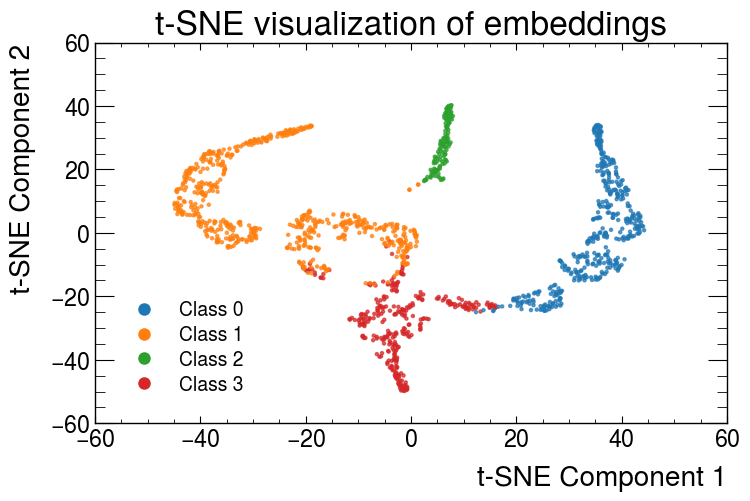

<Figure size 800x600 with 0 Axes>

In [20]:

# Print the average accuracy
print(f"Average accuracy: {np.mean(accuracies)}")

embeddings0 = embeddings[0] #np.concatenate(embeddings, axis=0)
all_targets0 = all_targets[0] #np.concatenate(all_targets, axis=0)

palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
fig, ax = plt.subplots(figsize=(8, 8/ 1.618))
plot_tsne_embeddings(ax, embeddings0, all_targets0, palette=palette)
plt.show()
plt.savefig("wow-unet-128.svg", format='svg')
plt.savefig("wow-unet-128.png", dpi=300)